In [4]:
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Simple CNN Architecture

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,8,3)
        self.conv2 = nn.Conv2d(8,16,5)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(16*4*4,10)

    def forward(self,x):
        # 1 × 28 × 28
        x = self.conv1(x)
        # 8 × 26 × 26
        x = self.relu(x)
        # 8 × 13 × 13
        x = self.pool(x)
        # 16 × 11 × 11
        x = self.conv2(x)
        # 16 × 11 × 11
        x = self.relu(x)
        # 16 × 4 × 5
        x = self.pool(x)
        # Flatten
        x = torch.flatten(x, start_dim=1)
        # 400 → 10
        x = self.fc(x)
        return x


### FashionMNIST Data

In [18]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


### Review the Images

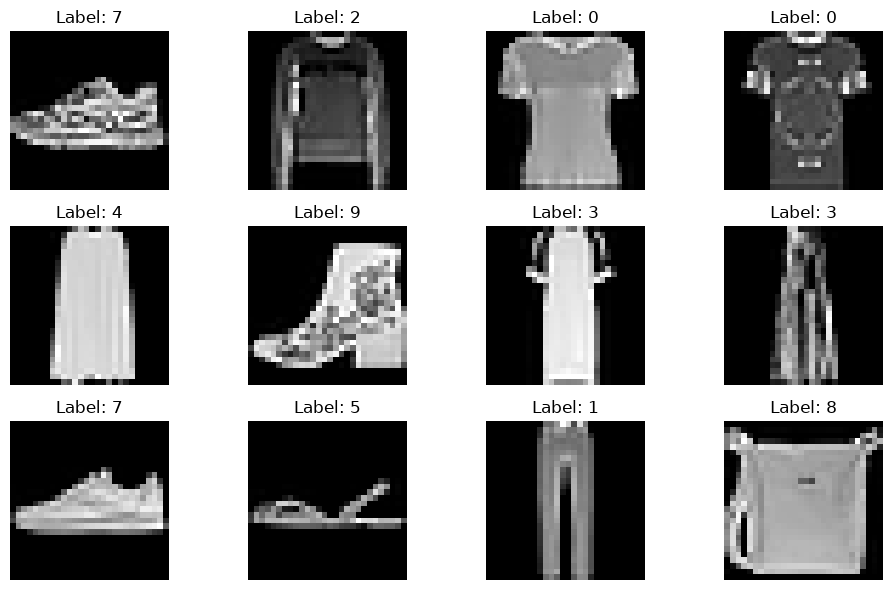

In [24]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Simple Model Training 

In [25]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        # Forward
        logits = model(X)
        # Loss
        loss = criterion(logits, y)
        # Clear old gradients
        optimizer.zero_grad()
        # Backpropagation
        loss.backward()
        # Update parameters
        optimizer.step()
        
        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {running_loss / len(train_loader):.4f}"
    )

Epoch [1/10], Loss: 0.6958
Epoch [2/10], Loss: 0.4768
Epoch [3/10], Loss: 0.4225
Epoch [4/10], Loss: 0.3960
Epoch [5/10], Loss: 0.3773
Epoch [6/10], Loss: 0.3615
Epoch [7/10], Loss: 0.3487
Epoch [8/10], Loss: 0.3394
Epoch [9/10], Loss: 0.3292
Epoch [10/10], Loss: 0.3217


### Evaluation 

In [23]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X, y in test_loader:

        logits = model(X)

        predictions = torch.argmax(logits, dim=1)

        total += y.size(0)

        correct += (predictions == y).sum().item()

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.869
